# GlitchGAN Paper — Figure Refinement

Produces publication-quality figure PDFs matching the paper style (revtex4-2 / PRD).
Figures saved to `figures/`.

**Sections**
1. Configuration & style
2. Figure 2 — DeepExtractor confusion matrix


## 1. Configuration & style

In [1]:
import io
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import Image, display as ipy_display
import scienceplots

# scienceplots 'science' style: Computer Modern font via usetex=True,
# matching revtex4-2 (PRD). Requires a LaTeX installation.
plt.style.use(["science"])

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)


def savefig(fig, name):
    """Save PDF to figures/ and display inline via BytesIO."""
    path = FIGURES_DIR / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    ipy_display(Image(buf.read()))
    print(f"Saved: {path}")


def _tex(label):
    """Escape underscores for LaTeX rendering."""
    return label.replace("_", r"\_")


print("Style loaded.")

Style loaded.


## 2. Figure 2 — DeepExtractor confusion matrix

Values extracted from `figures/deepextractor_confusion_matrix.png`.
7 true classes (rows) × 16 predicted classes (columns), 100 samples per class.
Style matches Figure 4 (GlitchGAN CM).

In [2]:
TRUE_LABELS = [
    "Blip", "Fast_Scattering", "Koi_Fish", "Low_Frequency_Burst",
    "Scattered_Light", "Tomte", "Whistle",
]

PRED_LABELS = [
    "Air_Compressor", "Blip", "Blip_Low_Frequency", "Extremely_Loud",
    "Fast_Scattering", "Koi_Fish", "Light_Modulation", "Low_Frequency_Burst",
    "Low_Frequency_Lines", "No_Glitch", "Paired_Doves", "Power_Line",
    "Repeating_Blips", "Scattered_Light", "Tomte", "Whistle",
]

# Counts — rows = true label, columns = predicted label (100 samples per class)
CM_RAW = np.array([
    #AC   Bl   BLF  EL   FS   KF   LM   LFB  LFL  NG   PD   PL   RB   SL   To   Wh
    [ 0, 100,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],  # Blip
    [ 1,   0,   1,   0,  77,   1,   0,   2,   0,   2,   1,   1,   3,   7,   4,   0],  # Fast_Scattering
    [ 0,   2,   0,  14,   0,  79,   1,   0,   0,   0,   0,   0,   4,   0,   0,   0],  # Koi_Fish
    [ 0,   0,   0,   0,   0,   0,   0, 100,   0,   0,   0,   0,   0,   0,   0,   0],  # Low_Frequency_Burst
    [ 0,   0,   0,   0,   3,   0,   0,   2,   5,   7,   0,   0,   0,  83,   0,   0],  # Scattered_Light
    [ 0,   0,   2,   0,   0,   2,   0,   0,   0,   0,   0,   0,   0,   0,  96,   0],  # Tomte
    [ 0,   0,   0,   0,   0,   0,   0,   0,   8,   0,   0,   0,   0,   0,   0,  92],  # Whistle
], dtype=float)

nan = np.nan

# Mean Gravity Spy confidence per cell — nan where count = 0
CM_CONF = np.array([
    #AC    Bl     BLF    EL     FS     KF     LM     LFB    LFL    NG     PD     PL     RB     SL     To     Wh
    [nan,  0.99,  nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan],  # Blip
    [0.76, nan,   0.88,  nan,   0.90,  0.98,  nan,   0.66,  nan,   0.65,  0.31,  0.92,  0.70,  0.85,  0.83,  nan],  # Fast_Scattering
    [nan,  0.79,  nan,   0.89,  nan,   0.92,  0.99,  nan,   nan,   nan,   nan,   nan,   0.78,  nan,   nan,   nan],  # Koi_Fish
    [nan,  nan,   nan,   nan,   nan,   nan,   nan,   1.00,  nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan],  # Low_Frequency_Burst
    [nan,  nan,   nan,   nan,   0.67,  nan,   nan,   0.91,  0.85,  0.94,  nan,   nan,   nan,   0.97,  nan,   nan],  # Scattered_Light
    [nan,  nan,   0.86,  nan,   nan,   0.91,  nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   0.98,  nan],  # Tomte
    [nan,  nan,   nan,   nan,   nan,   nan,   nan,   nan,   0.96,  nan,   nan,   nan,   nan,   nan,   nan,   0.99],  # Whistle
])

assert np.all(CM_RAW.sum(axis=1) == 100), "Row sums must equal 100"

correct = sum(CM_RAW[i, PRED_LABELS.index(TRUE_LABELS[i])] for i in range(len(TRUE_LABELS)))
accuracy = correct / CM_RAW.sum()
print(f"Correct: {int(correct)}/{int(CM_RAW.sum())}")
print(f"Accuracy: {accuracy:.2%}")

Correct: 627/700
Accuracy: 89.57%


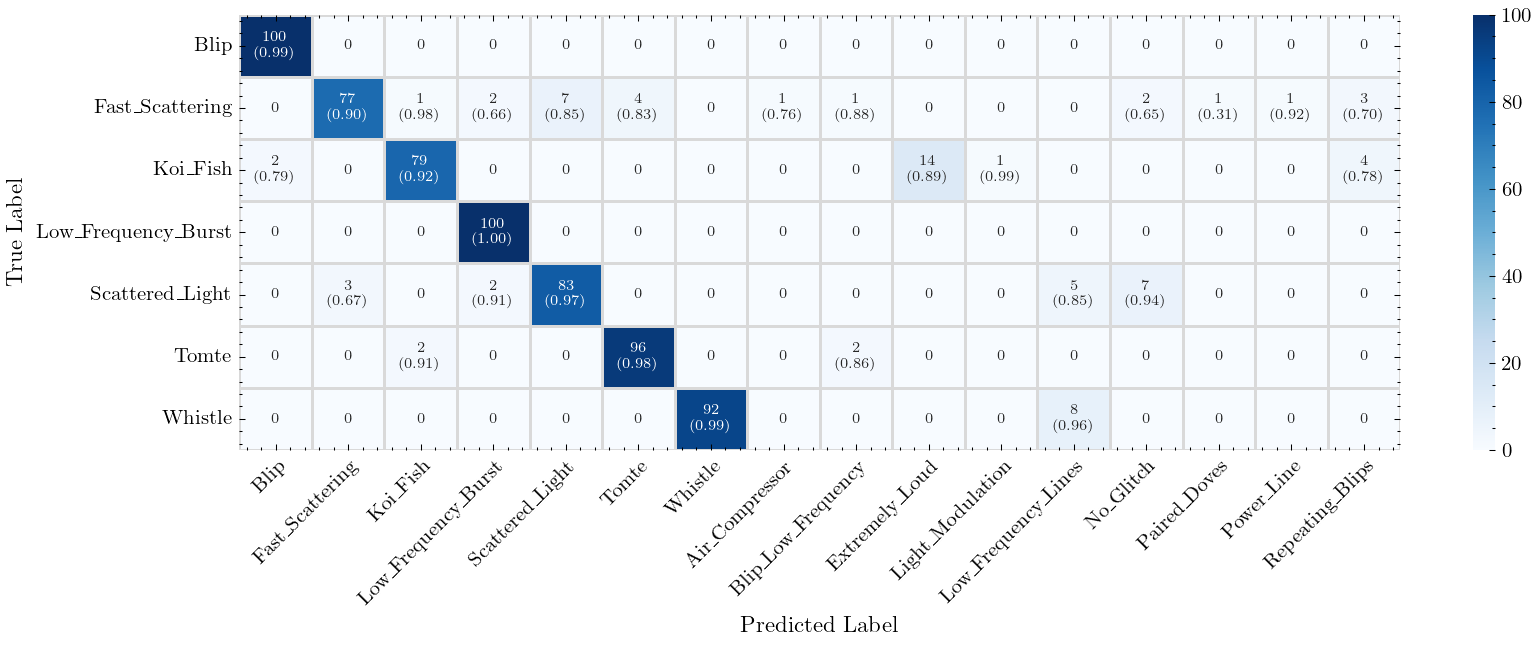

Saved: figures/deepextractor_confusion_matrix_refined.pdf


In [3]:
# Column order: true labels first (GAN/cDVGAN order), then remaining predicted classes
others = [l for l in PRED_LABELS if l not in TRUE_LABELS]
ordered_pred = TRUE_LABELS + others
col_idx = [PRED_LABELS.index(l) for l in ordered_pred]
cm_ordered   = CM_RAW[:, col_idx]
conf_ordered = CM_CONF[:, col_idx]

# Drop all-zero predicted columns
nonzero_cols = cm_ordered.sum(axis=0) > 0
cm_plot   = cm_ordered[:, nonzero_cols]
conf_plot = conf_ordered[:, nonzero_cols]
pred_plot = [l for l, keep in zip(ordered_pred, nonzero_cols) if keep]

# Build annotation: "count\n(conf)" for non-zero cells, bare "0" for zero
annot = np.empty_like(cm_plot, dtype=object)
for i in range(cm_plot.shape[0]):
    for j in range(cm_plot.shape[1]):
        n = int(cm_plot[i, j])
        c = conf_plot[i, j]
        annot[i, j] = "0" if n == 0 else f"{n}\n({c:.2f})"

fig_w = max(7.2, len(pred_plot) * 0.72)
fig, ax = plt.subplots(figsize=(fig_w, 4.5))

sns.heatmap(
    cm_plot,
    annot=annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=cm_plot.max(),
    linewidths=0.5,
    linecolor="0.85",
    cbar=True,
    annot_kws={"size": 7},
    xticklabels=[_tex(l) for l in pred_plot],
    yticklabels=[_tex(l) for l in TRUE_LABELS],
    ax=ax,
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()

savefig(fig, "deepextractor_confusion_matrix_refined")

## 3. Figure 4 — GlitchGAN confusion matrix

Values extracted from `figures/cDVGAN_CM.pdf`.
7 true classes (rows) × 11 predicted classes (columns), 25 samples per class.

In [4]:
GAN_PRED_LABELS = [
    "Blip", "Fast_Scattering", "Koi_Fish", "Low_Frequency_Burst",
    "Scattered_Light", "Tomte", "Whistle",
    "Blip_Low_Frequency", "Extremely_Loud", "Light_Modulation",
    "No_Glitch", "Paired_Doves", "Repeating_Blips", "Violin_Mode",
]

# Rows = true label, columns = predicted label (100 samples per class)
GAN_CM_RAW = np.array([
    #Bl   FS   KF   LFB  SL   To   Wh   BLF  EL   LM   NG   PD   RB   VM
    [88,   1,   1,   0,   0,   1,   0,   2,   0,   3,   0,   0,   4,   0],  # Blip
    [ 0,  72,   1,   3,   0,   2,   0,   0,   0,   0,   0,  22,   0,   0],  # Fast_Scattering
    [35,   1,  20,   0,   0,  19,   0,  23,   0,   1,   0,   0,   1,   0],  # Koi_Fish
    [ 0,   0,   0, 100,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],  # Low_Frequency_Burst
    [ 0,  52,   0,   5,  42,   0,   0,   0,   1,   0,   0,   0,   0,   0],  # Scattered_Light
    [ 0,   0,   1,   5,   0,  92,   0,   1,   0,   0,   0,   1,   0,   0],  # Tomte
    [ 0,   0,   0,   0,   0,   0,  94,   0,   0,   0,   3,   0,   0,   3],  # Whistle
], dtype=float)

nan = np.nan

# Mean Gravity Spy confidence per cell — nan where count = 0
GAN_CM_CONF = np.array([
    #Bl     FS     KF     LFB    SL     To     Wh     BLF    EL     LM     NG     PD     RB     VM
    [0.98,  0.81,  0.83,  nan,   nan,   0.66,  nan,   0.78,  nan,   0.77,  nan,   nan,   0.73,  nan],  # Blip
    [nan,   0.94,  0.63,  0.69,  nan,   1.00,  nan,   nan,   nan,   nan,   nan,   0.88,  nan,   nan],  # Fast_Scattering
    [0.92,  0.61,  0.79,  nan,   nan,   0.92,  nan,   0.75,  nan,   0.46,  nan,   nan,   1.00,  nan],  # Koi_Fish
    [nan,   nan,   nan,   1.00,  nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan],  # Low_Frequency_Burst
    [nan,   0.86,  nan,   0.84,  0.84,  nan,   nan,   nan,   0.64,  nan,   nan,   nan,   nan,   nan],  # Scattered_Light
    [nan,   nan,   0.93,  0.70,  nan,   0.99,  nan,   0.60,  nan,   nan,   nan,   0.63,  nan,   nan],  # Tomte
    [nan,   nan,   nan,   nan,   nan,   nan,   0.99,  nan,   nan,   nan,   0.60,  nan,   nan,   0.72],  # Whistle
])

assert np.all(GAN_CM_RAW.sum(axis=1) == 100), "Row sums must equal 100"

correct_gan = sum(
    GAN_CM_RAW[i, GAN_PRED_LABELS.index(TRUE_LABELS[i])]
    for i in range(len(TRUE_LABELS))
)
accuracy_gan = correct_gan / GAN_CM_RAW.sum()
print(f"Correct: {int(correct_gan)}/{int(GAN_CM_RAW.sum())}")
print(f"Accuracy: {accuracy_gan:.2%}")

Correct: 508/700
Accuracy: 72.57%


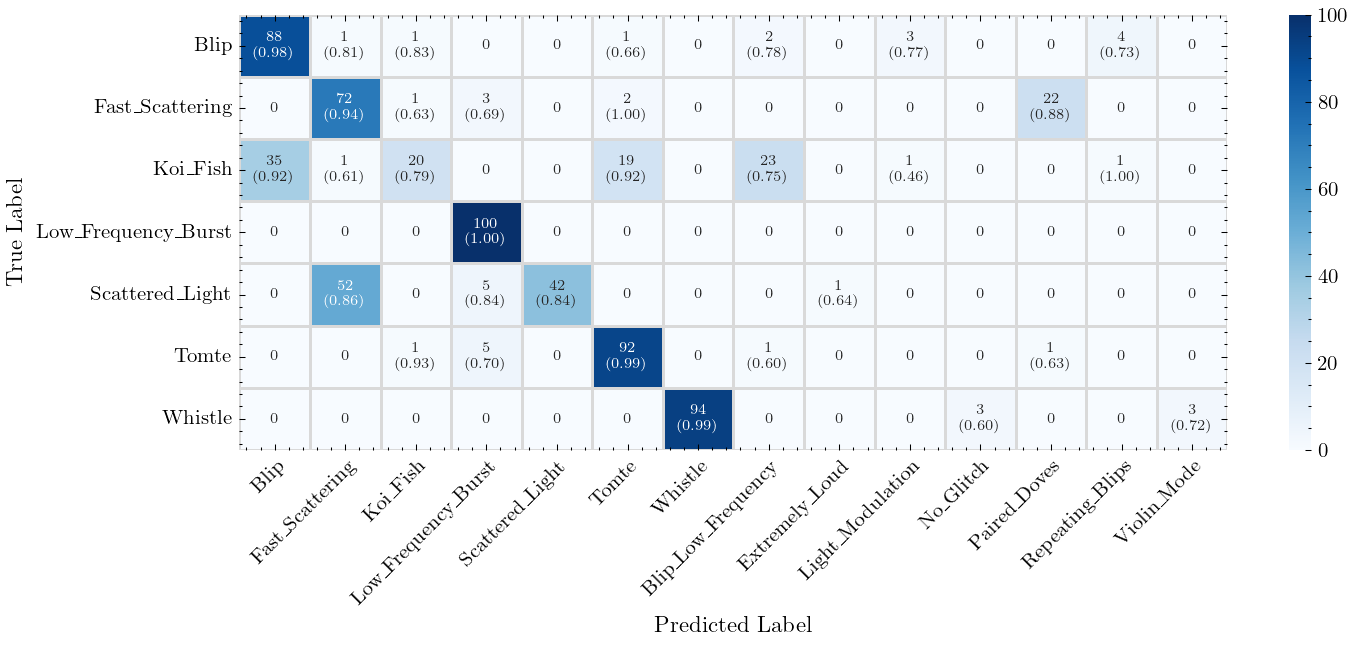

Saved: figures/glitchgan_confusion_matrix_refined.pdf


In [5]:
# Column order: true labels first (GAN order), then remaining predicted classes
others_gan = [l for l in GAN_PRED_LABELS if l not in TRUE_LABELS]
ordered_pred_gan = TRUE_LABELS + others_gan
col_idx_gan = [GAN_PRED_LABELS.index(l) for l in ordered_pred_gan]
cm_ordered_gan   = GAN_CM_RAW[:, col_idx_gan]
conf_ordered_gan = GAN_CM_CONF[:, col_idx_gan]

# Drop all-zero predicted columns
nonzero_cols_gan = cm_ordered_gan.sum(axis=0) > 0
cm_plot_gan   = cm_ordered_gan[:, nonzero_cols_gan]
conf_plot_gan = conf_ordered_gan[:, nonzero_cols_gan]
pred_plot_gan = [l for l, keep in zip(ordered_pred_gan, nonzero_cols_gan) if keep]

# Build annotation: "count\n(conf)" for non-zero cells, bare "0" for zero
annot_gan = np.empty_like(cm_plot_gan, dtype=object)
for i in range(cm_plot_gan.shape[0]):
    for j in range(cm_plot_gan.shape[1]):
        n = int(cm_plot_gan[i, j])
        c = conf_plot_gan[i, j]
        annot_gan[i, j] = "0" if n == 0 else f"{n}\n({c:.2f})"

fig_w = max(7.2, len(pred_plot_gan) * 0.72)
fig, ax = plt.subplots(figsize=(fig_w, 4.5))

sns.heatmap(
    cm_plot_gan,
    annot=annot_gan,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=cm_plot_gan.max(),
    linewidths=0.5,
    linecolor="0.85",
    cbar=True,
    annot_kws={"size": 7},
    xticklabels=[_tex(l) for l in pred_plot_gan],
    yticklabels=[_tex(l) for l in TRUE_LABELS],
    ax=ax,
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()

savefig(fig, "glitchgan_confusion_matrix_refined")

## 4. Appendix — DiT confusion matrix

Values extracted from `figures/dit_confusion_matrix.png`.
7 true classes (rows) × 19 predicted classes (columns), 100 samples per class.
DiT model evaluated via Gravity Spy classifier.

In [6]:
DIT_PRED_LABELS = [
    "1080Lines", "1400Ripples", "Air_Compressor", "Blip", "Blip_Low_Frequency",
    "Chirp", "Fast_Scattering", "Koi_Fish", "Light_Modulation",
    "Low_Frequency_Burst", "No_Glitch", "Paired_Doves", "Power_Line",
    "Repeating_Blips", "Scattered_Light", "Scratchy", "Tomte",
    "Violin_Mode", "Whistle",
]

# Rows = true label, columns = predicted label (100 samples per class)
DIT_CM_RAW = np.array([
    #1080 1400  AC    Bl   BLF   Ch    FS    KF    LM   LFB   NG    PD    PL    RB    SL    Sc    To    VM    Wh
    [  0,   0,   0,  48,   1,   0,   0,   0,   0,   0,  46,   0,   2,   0,   0,   0,   0,   3,   0],  # Blip
    [  0,   0,   2,   0,   0,   0,  72,   0,   0,   0,  18,   4,   0,   0,   4,   0,   0,   0,   0],  # Fast_Scattering
    [  0,   0,   1,  10,  24,   2,   2,  30,   3,   6,   2,   0,   0,  10,   0,   0,  10,   0,   0],  # Koi_Fish
    [  0,   0,   0,   0,   0,   0,   1,   0,   0,  87,  12,   0,   0,   0,   0,   0,   0,   0,   0],  # Low_Frequency_Burst
    [  0,   0,   0,   0,   0,   0,  36,   0,   0,   0,   0,   0,   0,   0,  64,   0,   0,   0,   0],  # Scattered_Light
    [  0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,  99,   0,   0],  # Tomte
    [  1,   1,   0,   0,   0,   0,   0,   0,   0,   0,  52,   0,   0,   0,   0,   0,   0,   1,  45],  # Whistle
], dtype=float)

nan = np.nan

DIT_CM_CONF = np.array([
    #1080  1400   AC    Bl    BLF   Ch    FS    KF    LM    LFB   NG    PD    PL    RB    SL    Sc    To    VM    Wh
    [nan,  nan,  nan,  0.88, 0.37,  nan,  nan,  nan,  nan,  nan,  0.76, nan,  0.31, nan,  nan,  nan,  nan,  0.51, nan],  # Blip
    [nan,  nan,  0.69, nan,  nan,   nan,  0.91, nan,  nan,  nan,  0.73, 0.82, nan,  nan,  0.86, nan,  nan,  nan,  nan],  # Fast_Scattering
    [nan,  nan,  0.37, 0.60, 0.69, 0.38, 0.44, 0.69, 0.70, 0.67, 0.61, nan,  nan,  0.67, nan,  nan,  0.59, nan,  nan],  # Koi_Fish
    [nan,  nan,  nan,  nan,  nan,   nan,  0.27, nan,  nan,  0.97, 0.75, nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan],  # Low_Frequency_Burst
    [nan,  nan,  nan,  nan,  nan,   nan,  0.92, nan,  nan,  nan,  nan,  nan,  nan,  nan,  0.93, nan,  nan,  nan,  nan],  # Scattered_Light
    [nan,  nan,  nan,  nan,  nan,   nan,  nan,  nan,  1.00, nan,  nan,  nan,  nan,  nan,  nan,  nan,  0.99, nan,  nan],  # Tomte
    [0.51, 0.73, nan,  nan,  nan,   nan,  nan,  nan,  nan,  nan,  0.86, nan,  nan,  nan,  nan,  nan,  nan,  0.47, 0.91],  # Whistle
])

assert np.all(DIT_CM_RAW.sum(axis=1) == 100), "Row sums must equal 100"

correct_dit = sum(
    DIT_CM_RAW[i, DIT_PRED_LABELS.index(TRUE_LABELS[i])]
    for i in range(len(TRUE_LABELS))
)
accuracy_dit = correct_dit / DIT_CM_RAW.sum()
print(f"Correct: {int(correct_dit)}/{int(DIT_CM_RAW.sum())}")
print(f"Accuracy: {accuracy_dit:.2%}")

Correct: 445/700
Accuracy: 63.57%


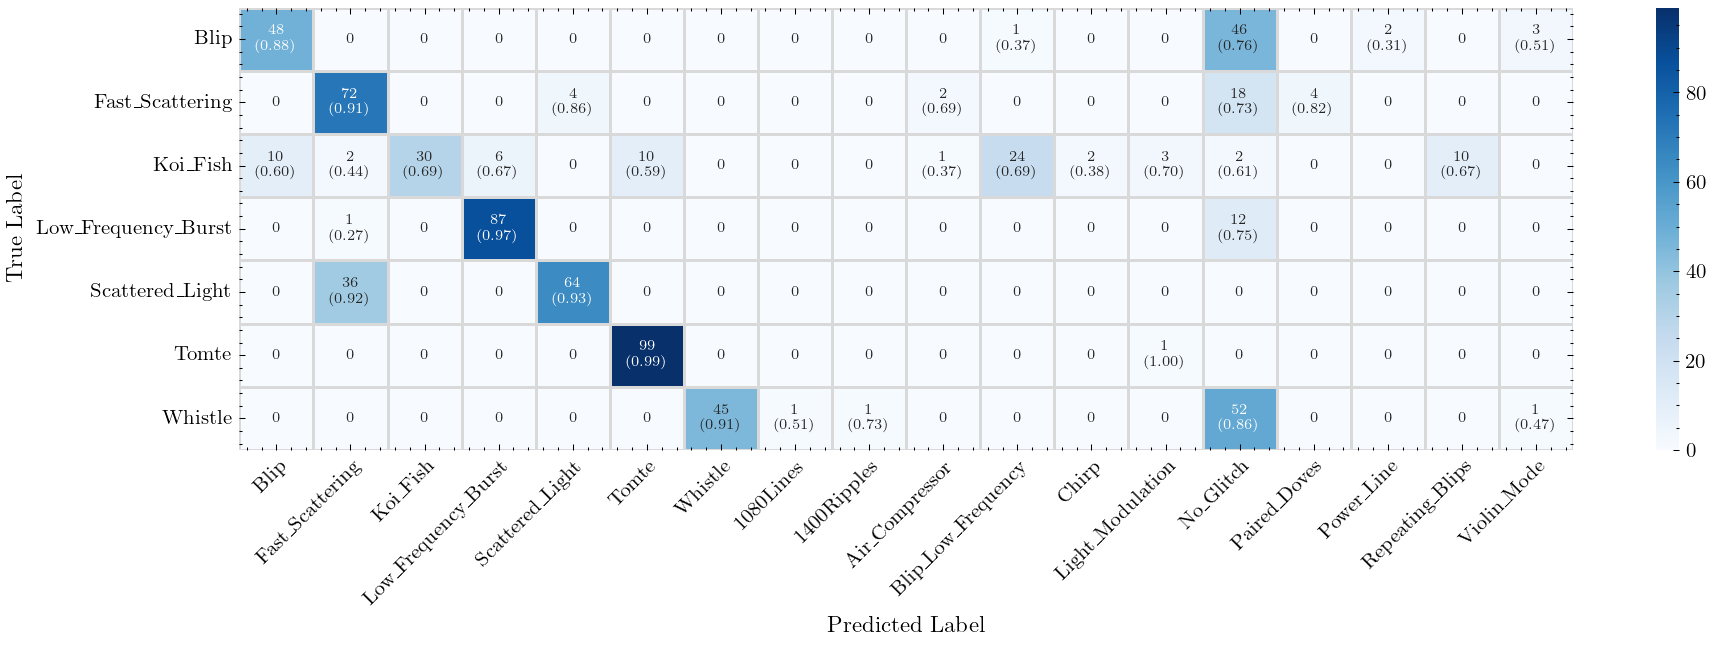

Saved: figures/dit_confusion_matrix_refined.pdf


In [7]:
# Column order: true labels first, then remaining predicted classes
others_dit = [l for l in DIT_PRED_LABELS if l not in TRUE_LABELS]
ordered_pred_dit = TRUE_LABELS + others_dit
col_idx_dit = [DIT_PRED_LABELS.index(l) for l in ordered_pred_dit]
cm_ordered_dit   = DIT_CM_RAW[:, col_idx_dit]
conf_ordered_dit = DIT_CM_CONF[:, col_idx_dit]

# Drop all-zero predicted columns
nonzero_cols_dit = cm_ordered_dit.sum(axis=0) > 0
cm_plot_dit   = cm_ordered_dit[:, nonzero_cols_dit]
conf_plot_dit = conf_ordered_dit[:, nonzero_cols_dit]
pred_plot_dit = [l for l, keep in zip(ordered_pred_dit, nonzero_cols_dit) if keep]

# Build annotation: "count\n(conf)" for non-zero cells, bare "0" for zero
annot_dit = np.empty_like(cm_plot_dit, dtype=object)
for i in range(cm_plot_dit.shape[0]):
    for j in range(cm_plot_dit.shape[1]):
        n = int(cm_plot_dit[i, j])
        c = conf_plot_dit[i, j]
        annot_dit[i, j] = "0" if n == 0 else f"{n}\n({c:.2f})"

fig_w = max(7.2, len(pred_plot_dit) * 0.72)
fig, ax = plt.subplots(figsize=(fig_w, 4.5))

sns.heatmap(
    cm_plot_dit,
    annot=annot_dit,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=cm_plot_dit.max(),
    linewidths=0.5,
    linecolor="0.85",
    cbar=True,
    annot_kws={"size": 7},
    xticklabels=[_tex(l) for l in pred_plot_dit],
    yticklabels=[_tex(l) for l in TRUE_LABELS],
    ax=ax,
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()

savefig(fig, "dit_confusion_matrix_refined")